# Space-Based Observations

Many missions depend on one satellite observing another: crosslinks route data through a communications constellation, relay satellites support spacecraft out of view of ground stations, and space situational awareness (SSA) sensors detect and track other spacecraft. Whether the observation is made by a sensor (optical or radar) or by a radio frequency (RF) link, it requires an unobstructed line of sight between the two satellites through space.

This TAT-C analysis function, `collect_space_observations`, finds the periods when each observing ("from") satellite can observe each observed ("to") satellite, subject to constraints on the line of sight between them: its slant range and its occlusion by the Earth. This analysis is purely geometric -- it does not consider link budgets, pointing, fields of view, relative velocity, or illumination conditions -- and represents a coarse estimate of observation opportunities suitable for early-stage mission analysis.

## Mathematical Basis

### Line-of-Sight Geometry

Assume the observing satellite (f, "from") and the observed satellite (t, "to") have positions $x_f$ and $x_t$, respectively, in a geocentric inertial frame. The observed satellite has position $x_{f,t} = x_t - x_f$ relative to the observing satellite, so the line of sight between them is the segment

$x(s) = x_f + s \, x_{f,t}, \qquad 0 \le s \le 1$

with slant range $\rho = ||x_{f,t}||$. Signals propagate along this straight line: atmospheric refraction is not modeled.

### Earth Occlusion

The line of sight is occluded if it passes through the Earth (or through its atmosphere, below some altitude). The lowest point of the line of sight is its *tangent point*: the point with minimum geodetic altitude above the WGS 84 reference ellipsoid, as in the [GNSS Radio Occultation](CollectRO.ipynb) and [Limb Sounding](CollectLimb.ipynb) analyses. Positions are expressed in the Earth-fixed frame and the polar axis is scaled by $k = (a + h) / (b + h)$, where $a$ and $b$ are the WGS 84 equatorial and polar radii and $h$ is the current estimate of the tangent point's geodetic altitude. This turns the surface of constant geodetic altitude $h$ into very nearly a sphere, so the tangent point is the closest approach of the scaled line to the origin:

$s^* = -\frac{x'_f \cdot x'_{f,t}}{x'_{f,t} \cdot x'_{f,t}}$

where primes denote scaled coordinates; three refinements of $h$ (starting from the closest approach to the geocenter) converge to well below a millimeter.

Unlike an occultation, which requires the tangent point to lie between the two satellites, the line of sight here is only the segment between them. If the tangent point of the full line lies beyond either satellite ($s^* < 0$ or $s^* > 1$), the lowest point of the segment is the nearer satellite itself, so the minimum altitude of the line of sight is

$h_{min} = h\left(x\left(\min(\max(s^*, 0), 1)\right)\right)$

where $h(x)$ is the geodetic altitude of position $x$.

### Observation Criteria

There are two criteria for a valid observation, each of which may be disabled.

First, the slant range must be within bounds, as set by sensor sensitivity or link budget:

$\rho_{min} \le \rho \le \rho_{max}$

Second, the line of sight must not be occluded by the Earth: its minimum geodetic altitude must be at least a grazing altitude,

$h_{min} \ge h_{graze}$

where $h_{graze} = 0$ only requires the line of sight to clear the WGS 84 ellipsoid, and a larger value (for example, 100 km) also avoids the atmosphere and the refraction, absorption, or background clutter it causes.

### Finding Observation Periods

The criteria are combined into a single residual function of time, which is not positive when (and only when) all criteria are met:

$f(t) = \max\left(\rho_{min} - \rho, \; \rho - \rho_{max}, \; h_{graze} - h_{min}\right)$

TAT-C evaluates $f$ for every pair of satellites at times spaced by half of a minimum observation duration (`min_duration`), propagating each satellite once for all pairs. Each change of sign between samples is then refined to a millisecond by the Illinois variant of the regula falsi method, for all pairs together. Observation periods (or gaps between them) shorter than `min_duration` may be missed.

For efficiency, the tangent point is only computed when needed: the minimum altitude of the line of sight is bounded by its closest approach $r$ to the geocenter, $r - a \le h_{min} \le r - b$, which decides the occlusion criterion except within a band of about 21 km.

## Analysis

### Observing Geostationary Satellites

The first scenario considers an SSA sensor in a dawn-dusk sun-synchronous orbit at 700 km altitude observing four geostationary satellites spaced 75 degrees apart in longitude. First, we define the scenario configuration: the analysis period (`start` to `end`) and the satellites.

In [1]:
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd

# scenario configuration
start = datetime(2026, 1, 1, tzinfo=timezone.utc)
duration = timedelta(hours=6)
end = start + duration

TAT-C `Satellite` objects define the observing sensor satellite and the observed geostationary satellites. Note that `collect_space_observations`, like `collect_ro_observations`, takes plain numeric arguments to describe the observation constraints, rather than an `Instrument` schema.

In [2]:
from tatc.schemas import GeosynchronousOrbit, Satellite, SunSynchronousOrbit

sensor = Satellite(
    name="Sensor",
    orbit=SunSynchronousOrbit(
        mean_altitude=700e3, equator_crossing_time="06:00", epoch=start
    ),
)

geo_sats = [
    Satellite(
        name=f"GEO {longitude:+d}",
        orbit=GeosynchronousOrbit(
            mean_altitude=35786e3, longitude=longitude, epoch=start
        ),
    )
    for longitude in [-75, 0, 75, 150]
]

TAT-C collects observation opportunities using the `collect_space_observations` function. It takes the observing satellite(s) (`from_satellites`), the analysis period (`start` and `end`), the observed satellite(s) (`to_satellites`, which default to the observing satellites), and the observation constraints:
 * `min_range` and `max_range` set the minimum and maximum slant range (in meters), if any.
 * `min_grazing_altitude` sets the minimum altitude (in meters) of the line of sight above the WGS 84 reference ellipsoid, or `None` to ignore Earth occlusion. Here, 100 km keeps the line of sight above most of the atmosphere.
 * `min_duration` sets the shortest observation period guaranteed to be detected (by default, 1 minute).

The outputs report each observation period including the following fields:
 * `target_hash`: a hash of the geometry that identifies the line of sight
 * `geometry`: a multi-line string geometry with the lines of sight from the observing to the observed satellite at the start and at the end of the period, through the satellites' longitude, latitude, and altitude
 * `from_satellite`: the observing satellite name
 * `to_satellite`: the observed satellite name
 * `start`: the start of the observation period
 * `end`: the end of the observation period

In [3]:
from tatc.analysis import collect_space_observations

geo_obs = collect_space_observations(
    sensor, start, end, geo_sats, min_grazing_altitude=100e3
)
display(geo_obs)

,target_hash,geometry,from_satellite,to_satellite,start,end
0,49348fbf523666cf,MULTILINESTRING Z ((90.01669 -0.11954 695866.3...,Sensor,GEO +0,2026-01-01 00:00:00+00:00,2026-01-01 00:53:12.629838870+00:00
1,2b3fc484259b76ef,MULTILINESTRING Z ((90.01669 -0.11954 695866.3...,Sensor,GEO +75,2026-01-01 00:00:00+00:00,2026-01-01 00:29:08.454750284+00:00
2,26211b0a8f4dc4c9,MULTILINESTRING Z ((90.01669 -0.11954 695866.3...,Sensor,GEO +150,2026-01-01 00:00:00+00:00,2026-01-01 00:30:28.349156277+00:00
3,04e1b614dfcad7e9,MULTILINESTRING Z ((62.68218 69.49219 704872.0...,Sensor,GEO -75,2026-01-01 00:19:28.380035399+00:00,2026-01-01 01:17:36.139695110+00:00
4,3ecf0703597dbf8f,MULTILINESTRING Z ((-104.79318 -11.5408 698079...,Sensor,GEO +150,2026-01-01 00:52:29.161049457+00:00,2026-01-01 03:12:38.346787200+00:00
5,9254c1deee9c5e26,MULTILINESTRING Z ((-119.45196 -57.79396 71524...,Sensor,GEO +0,2026-01-01 01:05:22.801055392+00:00,2026-01-01 02:14:07.087751201+00:00
6,4fbec55741a23c46,MULTILINESTRING Z ((-134.24212 -72.43257 71959...,Sensor,GEO +75,2026-01-01 01:09:41.663311833+00:00,2026-01-01 02:07:00.119781547+00:00
7,8cc4abf7bb875ecc,MULTILINESTRING Z ((46.57242 60.38546 703149.1...,Sensor,GEO -75,2026-01-01 01:55:29.717901273+00:00,2026-01-01 02:57:18.475474783+00:00
8,b0a270ea330d3848,MULTILINESTRING Z ((-151.79938 -67.41673 71832...,Sensor,GEO +75,2026-01-01 02:46:51.276816339+00:00,2026-01-01 03:45:36.300439008+00:00
9,cbc4304a1853f4de,MULTILINESTRING Z ((-161.88015 -73.90399 71990...,Sensor,GEO +0,2026-01-01 02:48:50.554901965+00:00,2026-01-01 03:48:23.182816153+00:00


A timeline shows when each geostationary satellite is observable. Each is hidden behind the Earth for part of every orbit of the sensor, at different times for satellites at different longitudes. Adding a maximum slant range (here, a detection range of 40,000 km) further shortens each period, as the sensor is farther than this range from the satellite for part of its orbit.

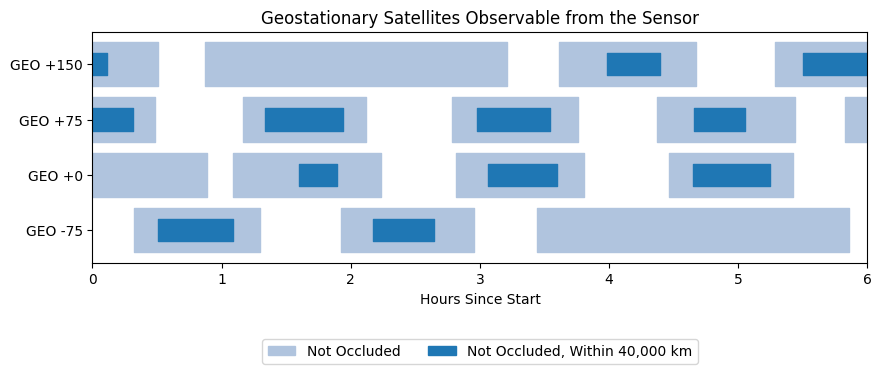

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

geo_obs_range = collect_space_observations(
    sensor, start, end, geo_sats, max_range=40000e3, min_grazing_altitude=100e3
)


def to_hours(times):
    return (times - start).dt.total_seconds() / 3600


fig, ax = plt.subplots(figsize=(10, 3))
for i, sat in enumerate(geo_sats):
    for obs, color, height in [(geo_obs, "lightsteelblue", 0.8), (geo_obs_range, "C0", 0.4)]:
        sat_obs = obs[obs.to_satellite == sat.name]
        ax.broken_barh(
            list(zip(to_hours(sat_obs.start), to_hours(sat_obs.end) - to_hours(sat_obs.start))),
            (i - height / 2, height),
            color=color,
        )
ax.set_yticks(range(len(geo_sats)), [sat.name for sat in geo_sats])
ax.set_xlim(0, duration / timedelta(hours=1))
ax.set_xlabel("Hours Since Start")
ax.set_title("Geostationary Satellites Observable from the Sensor")
ax.legend(
    handles=[
        Patch(color="lightsteelblue", label="Not Occluded"),
        Patch(color="C0", label="Not Occluded, Within 40,000 km"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
)
plt.show()

Each row's `geometry` records the lines of sight at the start and end of the observation period. Plotting them on a map (as great-circle arcs between the sub-satellite points, for illustration) together with the sensor's orbit track shows that each observation starts and ends with the sensor far from the geostationary satellite's sub-satellite point, as it passes into or out of view behind the limb of the Earth (as seen from the geostationary satellite).

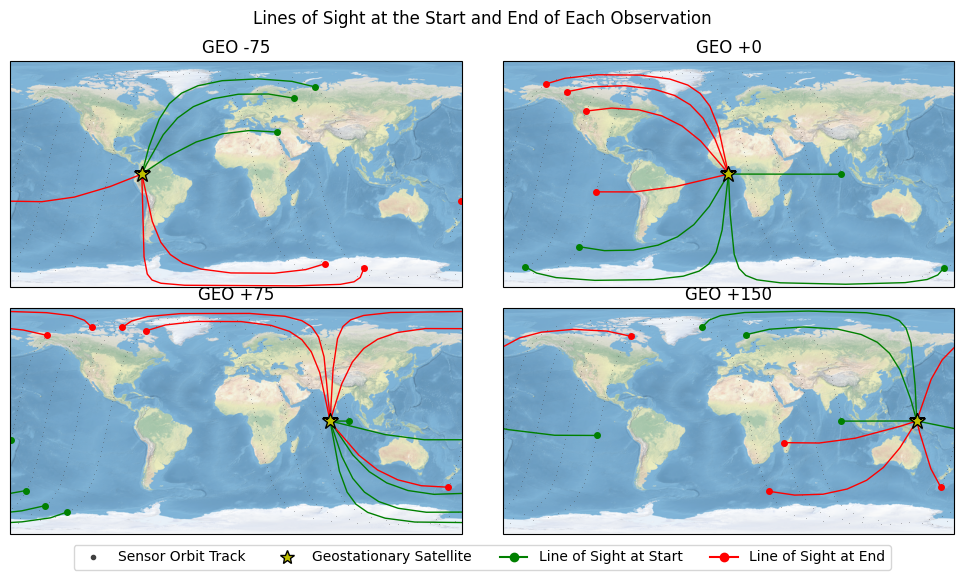

In [5]:
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
from tatc.analysis import collect_orbit_track

times = [start + i * timedelta(minutes=1) for i in range(duration // timedelta(minutes=1))]
orbit_track = collect_orbit_track(sensor, times)

fig, axes = plt.subplots(
    2, 2, figsize=(10, 5.5), subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, sat in zip(axes.flat, geo_sats):
    orbit_track.plot(
        ax=ax, marker=".", color="0.25", markersize=0.5, lw=0, transform=ccrs.PlateCarree()
    )
    for _, obs in geo_obs[geo_obs.to_satellite == sat.name].iterrows():
        for line, color in zip(obs.geometry.geoms, ["g", "r"]):
            (lon_f, lat_f, _), (lon_t, lat_t, _) = line.coords
            ax.plot([lon_f, lon_t], [lat_f, lat_t], color=color, lw=1, transform=ccrs.Geodetic())
            ax.plot(lon_f, lat_f, "o", color=color, ms=4, transform=ccrs.PlateCarree())
    ax.plot(sat.orbit.longitude, 0, "*", color="y", ms=12, mec="k", transform=ccrs.PlateCarree())
    ax.stock_img()
    ax.set_global()
    ax.set_title(sat.name)
fig.legend(
    handles=[
        Line2D([0], [0], marker=".", color="0.25", lw=0, label="Sensor Orbit Track"),
        Line2D([0], [0], marker="*", color="y", mec="k", ms=10, lw=0, label="Geostationary Satellite"),
        Line2D([0], [0], marker="o", color="g", label="Line of Sight at Start"),
        Line2D([0], [0], marker="o", color="r", label="Line of Sight at End"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
)
fig.suptitle("Lines of Sight at the Start and End of Each Observation")
fig.tight_layout()
plt.show()

### Crosslinks in an Iridium-like Constellation

The second scenario considers the crosslinks of a constellation similar to Iridium: 66 satellites at 780 km altitude and 86.4 degree inclination in six planes, arranged in a Walker star configuration with a narrower 22 degree seam between the planes of counter-rotating satellites. Each Iridium satellite maintains crosslinks with the satellites ahead of and behind it in its plane (about 4,000 km away) and with satellites in the adjacent planes.

The analysis below finds every period when two members are within 4,500 km of each other with a line of sight above 100 km altitude, over one day. Without `to_satellites`, each member is both an observing and an observed satellite.

In [6]:
from tatc.schemas import CircularOrbit, WalkerConstellation

iridium = WalkerConstellation(
    name="Iridium",
    configuration="star",
    orbit=CircularOrbit(altitude=780e3, inclination=86.4, epoch=start),
    number_satellites=66,
    number_planes=6,
    relative_spacing=3,
    seam_spacing=22,
)
members = iridium.generate_members()

duration = timedelta(days=1)
end = start + duration
max_range = 4500e3  # m
min_grazing_altitude = 100e3  # m

links = collect_space_observations(
    members, start, end, max_range=max_range, min_grazing_altitude=min_grazing_altitude
)
display(links)

,target_hash,geometry,from_satellite,to_satellite,start,end
0,16c8bf9f2f21b076,MULTILINESTRING Z ((-100.66875 -0.12016 775933...,Iridium 01,Iridium 02,2026-01-01 00:00:00+00:00,2026-01-02 00:00:00+00:00
1,d686dbb4486ffb25,MULTILINESTRING Z ((-100.66875 -0.12016 775933...,Iridium 01,Iridium 11,2026-01-01 00:00:00+00:00,2026-01-02 00:00:00+00:00
2,3d17363857662941,MULTILINESTRING Z ((-100.66875 -0.12016 775933...,Iridium 01,Iridium 12,2026-01-01 00:00:00+00:00,2026-01-02 00:00:00+00:00
3,e84ba0da8ec9b97c,MULTILINESTRING Z ((-100.66875 -0.12016 775933...,Iridium 01,Iridium 22,2026-01-01 00:00:00+00:00,2026-01-02 00:00:00+00:00
4,bc63f6ce82fb5103,MULTILINESTRING Z ((-100.66875 -0.12016 775933...,Iridium 01,Iridium 59,2026-01-01 00:00:00+00:00,2026-01-01 00:04:07.378175971+00:00
...,...,...,...,...,...,...
28335,780620bb6515ae5e,MULTILINESTRING Z ((-141.77413 -75.36747 80029...,Iridium 47,Iridium 15,2026-01-01 23:59:54.531927562+00:00,2026-01-02 00:00:00+00:00
28336,f4a4b18ab4a83f5b,MULTILINESTRING Z ((-96.00084 59.27987 783007....,Iridium 10,Iridium 42,2026-01-01 23:59:55.351749895+00:00,2026-01-02 00:00:00+00:00
28337,6f090bd44ba334e6,MULTILINESTRING Z ((-32.80084 59.27987 783007....,Iridium 31,Iridium 63,2026-01-01 23:59:55.351749895+00:00,2026-01-02 00:00:00+00:00
28338,f4a4b18ab4a83f5b,MULTILINESTRING Z ((6.61289 75.35818 785820.15...,Iridium 42,Iridium 10,2026-01-01 23:59:55.351749895+00:00,2026-01-02 00:00:00+00:00


Pairs of satellites are ordered: since the constraints are symmetric, each link appears twice, once in each direction, with the same `start`, `end`, and `target_hash` (the line of sight is the same, regardless of direction). Future constraints that depend on direction (such as the observing satellite's orientation) may distinguish them. To count each link once, keep only one direction of each pair.

In [7]:
unique_links = links[links.from_satellite < links.to_satellite]
print(f"{len(links)} directed observation periods, {len(unique_links)} links")
print(
    f"{unique_links.groupby(['from_satellite', 'to_satellite']).ngroups} pairs of satellites linked at least once"
)

28340 directed observation periods, 14170 links
660 pairs of satellites linked at least once


A snapshot of the network shows the satellites' positions and the links available at a single time, distinguishing links within a plane from links between planes. The planes converge near the poles, where satellites in adjacent planes come within range of more of their neighbors. Across the seam, counter-rotating satellites pass each other too quickly to sustain long links.

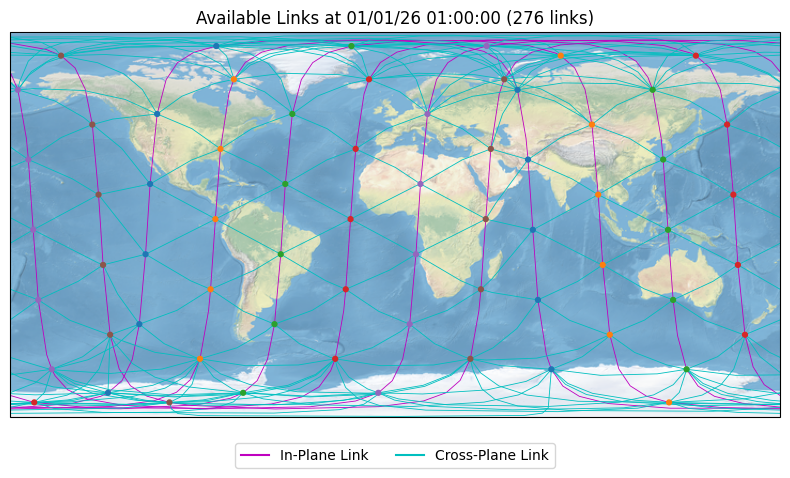

In [8]:
names = [member.name for member in members]
plane = {name: i // iridium.get_satellites_per_plane() for i, name in enumerate(names)}


def plot_network(ax, time):
    track = collect_orbit_track(members, [time]).set_index("satellite")
    active = unique_links[(unique_links.start <= time) & (unique_links.end >= time)]
    for _, link in active.iterrows():
        p_f, p_t = track.geometry[link.from_satellite], track.geometry[link.to_satellite]
        ax.plot(
            [p_f.x, p_t.x],
            [p_f.y, p_t.y],
            color="m" if plane[link.from_satellite] == plane[link.to_satellite] else "c",
            lw=0.6,
            transform=ccrs.Geodetic(),
        )
    ax.scatter(
        track.geometry.x,
        track.geometry.y,
        c=[f"C{plane[name]}" for name in track.index],
        s=12,
        zorder=3,
        transform=ccrs.PlateCarree(),
    )
    return len(active)


time = start + timedelta(hours=1)
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
num_links = plot_network(ax, time)
ax.stock_img()
ax.set_global()
ax.legend(
    handles=[
        Line2D([0], [0], color="m", label="In-Plane Link"),
        Line2D([0], [0], color="c", label="Cross-Plane Link"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
)
ax.set_title(f"Available Links at {time.strftime('%x %X')} ({num_links} links)")
plt.show()

A timeline of the links of a single satellite (here, the first member, in the first plane) shows three kinds of links:
 * persistent links to its neighbors ahead and behind in the same plane and to the two nearest satellites in the adjacent, co-rotating plane,
 * intermittent links to satellites in other co-rotating planes, which come within range as the planes converge near the poles, and
 * a rapid succession of brief links to the counter-rotating satellites in the last plane, across the seam, each lasting only a few minutes.

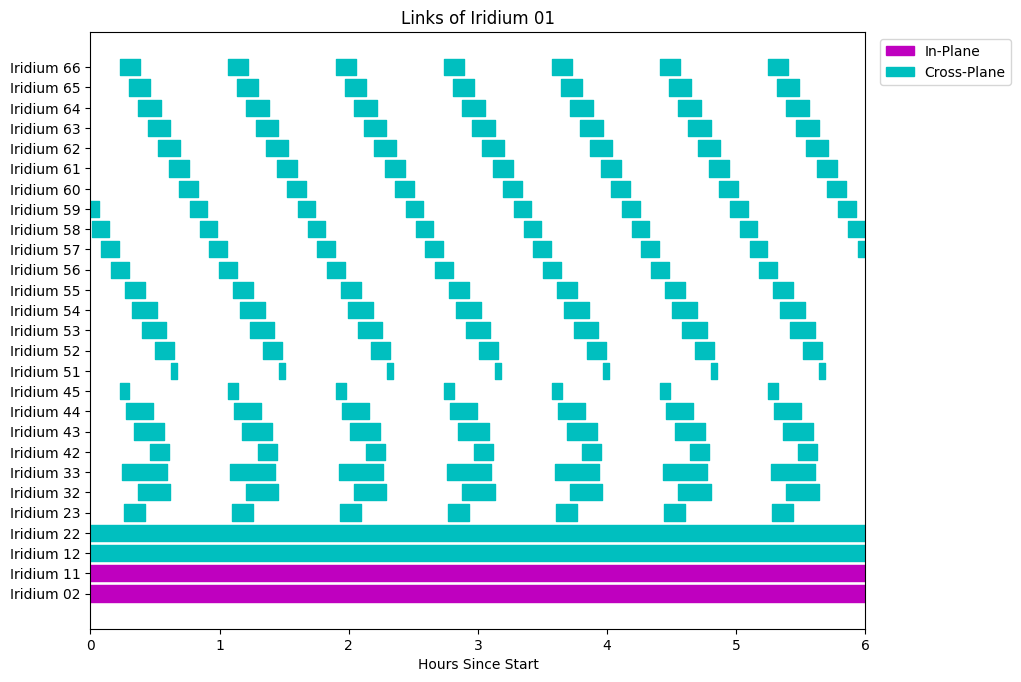

In [9]:
sat_name = names[0]
sat_links = links[links.from_satellite == sat_name]
neighbors = sorted(sat_links.to_satellite.unique())

fig, ax = plt.subplots(figsize=(10, 0.25 * len(neighbors) + 1))
for i, neighbor in enumerate(neighbors):
    neighbor_links = sat_links[sat_links.to_satellite == neighbor]
    ax.broken_barh(
        list(
            zip(
                to_hours(neighbor_links.start),
                to_hours(neighbor_links.end) - to_hours(neighbor_links.start),
            )
        ),
        (i - 0.4, 0.8),
        color="m" if plane[neighbor] == plane[sat_name] else "c",
    )
ax.set_yticks(range(len(neighbors)), neighbors)
ax.set_xlim(0, 6)
ax.set_xlabel("Hours Since Start")
ax.set_title(f"Links of {sat_name}")
ax.legend(
    handles=[Patch(color="m", label="In-Plane"), Patch(color="c", label="Cross-Plane")],
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
)
plt.show()

Counting the links available to the same satellite over time, together with its latitude, shows how the number of cross-plane links peaks as it passes over the poles.

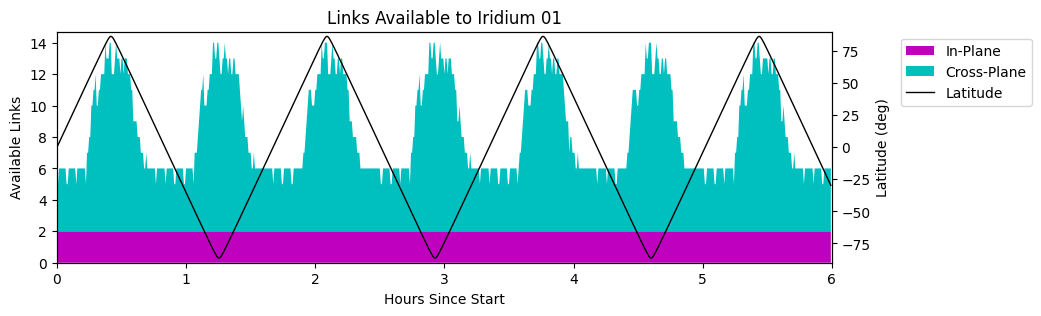

In [10]:
sample_times = [start + i * timedelta(seconds=30) for i in range(timedelta(hours=6) // timedelta(seconds=30))]
sample_index = pd.DatetimeIndex(sample_times)


def count_links(sat_links):
    return np.sum(
        [(sample_index >= link.start) & (sample_index <= link.end) for _, link in sat_links.iterrows()],
        axis=0,
    )


in_plane = sat_links.to_satellite.map(plane) == plane[sat_name]
sat_track = collect_orbit_track(members[0], sample_times)

fig, ax = plt.subplots(figsize=(10, 3))
hours = to_hours(pd.Series(sample_index))
ax.stackplot(
    hours,
    count_links(sat_links[in_plane]),
    count_links(sat_links[~in_plane]),
    colors=["m", "c"],
    labels=["In-Plane", "Cross-Plane"],
)
ax.set_xlim(0, 6)
ax.set_xlabel("Hours Since Start")
ax.set_ylabel("Available Links")
ax_lat = ax.twinx()
ax_lat.plot(hours, sat_track.geometry.y, "k", lw=1, label="Latitude")
ax_lat.set_ylabel("Latitude (deg)")
ax_lat.set_ylim(-90, 90)
ax_lat.legend(
    handles=ax.get_legend_handles_labels()[0] + ax_lat.get_legend_handles_labels()[0],
    loc="upper left",
    bbox_to_anchor=(1.08, 1),
)
ax.set_title(f"Links Available to {sat_name}")
plt.show()

The maximum slant range has a strong effect on the network. The mean number of links available to each satellite (the total duration of its observation periods, divided by the analysis period) shows the effect over a range of maximum slant ranges. Below about 4,030 km (the distance between neighbors in a plane), satellites lose the links to their neighbors in the same plane, and above about 6,500 km, Earth occlusion rather than range limits the network.

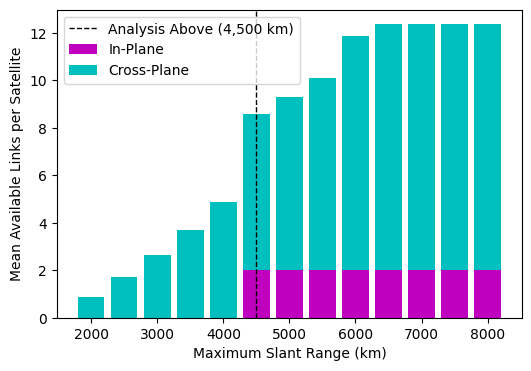

In [11]:
max_ranges = np.arange(2000e3, 8001e3, 500e3)
mean_links = []
for value in max_ranges:
    obs = collect_space_observations(
        members, start, end, max_range=value, min_grazing_altitude=min_grazing_altitude
    )
    in_plane = obs.from_satellite.map(plane) == obs.to_satellite.map(plane)
    total = (obs.end - obs.start) / duration / len(members)
    mean_links.append((total[in_plane].sum(), total[~in_plane].sum()))

mean_in_plane, mean_cross_plane = np.array(mean_links).T
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(max_ranges / 1e3, mean_in_plane, width=400, color="m", label="In-Plane")
ax.bar(
    max_ranges / 1e3,
    mean_cross_plane,
    width=400,
    bottom=mean_in_plane,
    color="c",
    label="Cross-Plane",
)
ax.axvline(max_range / 1e3, color="k", ls="--", lw=1, label=f"Analysis Above ({max_range / 1e3:,.0f} km)")
ax.set_xlabel("Maximum Slant Range (km)")
ax.set_ylabel("Mean Available Links per Satellite")
ax.legend(loc="upper left")
plt.show()

An animation shows the evolution of the network over one orbit (about 100 minutes), at 4-minute frames.

In [12]:
import matplotlib.animation as animation
from IPython.display import HTML

# embed frames as JPEG images, which are much smaller than PNG
plt.rcParams["animation.frame_format"] = "jpeg"

fig, ax = plt.subplots(figsize=(8, 4), dpi=72, subplot_kw={"projection": ccrs.PlateCarree()})

frame_duration = timedelta(minutes=4)
num_frames = iridium.orbit.get_orbit_period() // frame_duration


def animate(frame):
    ax.clear()
    time = start + frame * frame_duration
    num_links = plot_network(ax, time)
    ax.set_global()
    ax.coastlines()
    ax.set_aspect("equal")
    ax.set_title(f"{time.strftime('%x %X')} ({num_links} links)")
    fig.tight_layout()


ani = animation.FuncAnimation(fig, animate, frames=num_frames, interval=200, blit=False)
display(HTML(ani.to_jshtml()))
plt.close()